#Parcial

Jesus David Serpa Pajaro
cc 1192914660

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
grad=180/np.pi
rad=np.pi/180

## Fenomenos observacionales de las estrellas

### a)identifique qué variables contiene el archivo y cuáles son sus  unidades.

* __ID__ = Nombres de las estrellas
* __AR[hms]__ = Ascencion Recta esta en [Horas,minutos,segudos]
* __DEC[dms]__= Declinacion está en [Grados,minutos de arco,segundos de arco]
* __mu-ra*cos(dec) [mas/yr]__ = Movimiento propio de la asencion recta (corregido)en [milisegundos de arco/año]
* __mu-dec[mas/yr]__ = Movimiento propio de la declinacion en [milisegundos de arco/año]
* __plx[mas]__= Paralaje [milisegundos de arco]
+ __radvel [km/s]__= Velocidad radial[kilometros/segundos]

### (b) Ahora, lea el archivo y dé el formato adecuado a cada variable.


In [ ]:
#para leer el archivo, subimos el archivo de csv la nube para poder leerlo por con pandas
url ="https://raw.githubusercontent.com/jesuserpajaro/Udea/main/stars.csv"
df = pd.read_csv(url)


In [ ]:

df

,ID,AR [hms],DEC [dms],mu-ra*cos(dec) [mas/yr],mu-dec [mas/yr],plx [mas],radvel [km/s]
0,* tau Cyg,21 14 47.493,+38 02 43.144,196.990,410.280,49.1600,-20.900
1,* sig Cyg,21 17 24.952,+39 23 40.853,-0.130,-3.580,1.1300,-5.300
2,* 6 Lac,22 30 29.26,+43 07 24.156,-1.980,-5.360,1.9000,-8.700
3,* 11 Lac,22 40 30.859,+44 16 34.704,93.830,10.710,9.8000,-11.530
4,* psi And,23 46 2.047,+46 25 12.986,8.446,-7.143,1.6352,-23.163
...,...,...,...,...,...,...,...
1592,* 32 Eri A,03 54 17.502,-02 57 17.04,26.330,0.079,9.4562,26.300
1593,* del Ser A,15 34 48.145,+10 32 19.88,-73.952,5.748,10.8056,-20.820
1594,* phi Per,01 43 39.638,+50 41 19.433,24.590,-14.010,4.5400,0.800
1595,* alf Eri,01 37 42.845,-57 14 12.31,87.000,-38.240,23.3900,18.600


In [ ]:

#Tomando en cuenta que los las componentes de a ascencion recta y la declinacion estan en tipo string hay que pasarlos de strig a flotante


#El sigueinte codigo lo que hace es coger cada termino a y ademas de pasarlo a flotante lo pasamos de grados min y seg a decimales,

# Ascencion recta
ar = []
for i in df.index:
  a = float(df['AR [hms]'][i].split(' ')[0])  + float(df['AR [hms]'][i].split(' ')[1]) /60 + float(df['AR [hms]'][i].split(' ')[2])/3600 # sumar cada termino, los seguos /60 y los minutos /3600 para dejarlo en grados
  ar.append(a)

asr = []
for i in ar:
  r = i *15
  asr.append(r)

# Declinacion
dcl = []
for i in df.index:
  if df['DEC [dms]'][i][0]=='-': #garantizar que si es negativo cada elemento se resta para que de la suma negativa
    a =float(df['DEC [dms]'][i].split(' ')[0])  - float(df['DEC [dms]'][i].split(' ')[1]) /60 - float(df['DEC [dms]'][i].split(' ')[2])/3600
    dcl.append(a)
  elif df['DEC [dms]'][i][0]=='+':
    a =float(df['DEC [dms]'][i].split(' ')[0])  + float(df['DEC [dms]'][i].split(' ')[1]) /60 + float(df['DEC [dms]'][i].split(' ')[2])/3600
    dcl.append(a)


#nuevos datos de la ascencion recta y la declinacion

#print("Datos de la ascencion recta",asr)
#print("Datos de la declinacion",dcl)



In [ ]:
#Modificamos la tabla con los datos

#agregamos los nuevos datos de ascencion recta y declinacion a la tabla
df['mu-ra*cos(dec) [mas/yr]']= df['mu-ra*cos(dec) [mas/yr]'].astype(float)
df['mu-dec [mas/yr]']= df['mu-dec [mas/yr]'].astype(float)
df['AR [hms]']=asr
df['DEC [dms]']=dcl
df=df.rename(columns={'AR [hms]':'AR [°]','DEC [dms]':'DEC [°]'})
df

,ID,AR [°],DEC [°],mu-ra*cos(dec) [mas/yr],mu-dec [mas/yr],plx [mas],radvel [km/s]
0,* tau Cyg,318.697887,38.045318,196.990,410.280,49.1600,-20.900
1,* sig Cyg,319.353967,39.394681,-0.130,-3.580,1.1300,-5.300
2,* 6 Lac,337.621917,43.123377,-1.980,-5.360,1.9000,-8.700
3,* 11 Lac,340.128579,44.276307,93.830,10.710,9.8000,-11.530
4,* psi And,356.508529,46.420274,8.446,-7.143,1.6352,-23.163
...,...,...,...,...,...,...,...
1592,* 32 Eri A,58.572925,-2.954733,26.330,0.079,9.4562,26.300
1593,* del Ser A,233.700604,10.538856,-73.952,5.748,10.8056,-20.820
1594,* phi Per,25.915158,50.688731,24.590,-14.010,4.5400,0.800
1595,* alf Eri,24.428521,-57.236753,87.000,-38.240,23.3900,18.600


In [ ]:
df[df['mu-ra*cos(dec) [mas/yr]']=='1.078.609']

,ID,AR [°],DEC [°],mu-ra*cos(dec) [mas/yr],mu-dec [mas/yr],plx [mas],radvel [km/s]


### c) Escriba un programa para calcular el cambio en ascensión recta (Aa) y en declinación (Ad) de las estrellas, dada la diferencia de tiempo entre la época de las coordenadas y la fecha a la que se quiere corregir. Considere los cambios por precesión, nutación y movimiento propio.

In [ ]:
def presecion(ar,dec,fecha):

    ar= ar*rad
    dec=dec*rad

    Fj=pd.to_datetime(fecha).to_julian_date()
    T=(Fj-2451545.5)/36525

    M= 1.2812323*T + 3.879e-4 * T**2 + 1.101e-5*T**3
    N= 0.5567530*T - 1.185e-4 * T**2 - 1.16e-5*T**3

    M=M*rad
    N=N*rad

    αm= ar + 0.5*(M + N* np.sin(ar)*np.tan(dec))
    δm= dec+ 0.5*N*np.cos(αm)

    Δα= M + N*np.sin(αm)*np.tan(δm)
    Δδ= N * np.cos(αm)

    return Δα*grad,Δδ*grad

In [ ]:
def nutacion(ar,dec,fecha):
    ar= ar*rad
    dec=dec*rad

    Fj=pd.to_datetime(fecha).to_julian_date()
    T=(Fj-2451545.5)/36525

    Ω= (125.04 - 1934.13*T)%360
    D= (297.85 + 445267.11*T)%360
    F= (93.27 + 483202.0175*T)%360

    Ω=Ω*rad
    D=D*rad
    F=F*rad

    Δψ= -17.2/3600 *np.sin(Ω) + 0.2/3600* np.sin(2*Ω) - 1.3/3600 *np.sin(2*Ω + 2*F - 2*D) - 0.2/3600 *np.sin(2*Ω + 2*F)
    Δϵ=9.2/3600 * np.cos(Ω) - 0.1/3600 * np.cos(Ω) + 0.6/3600 * np.cos(2*Ω + 2*F - 2*D)

    ϵ =23 + (26/60) + (21.4/3600) - (46.81/3600)*T
    ϵv= ϵ + Δϵ

    Δα= (np.cos(ϵ) + np.sin(ϵ)*np.sin(ar)*np.tan(dec))*Δψ - np.cos(dec)*np.tan(dec)*Δϵ
    Δδ= np.sin(ϵ) * np.cos(ar)*Δψ + np.sin(ar)*Δϵ

    return Δα*grad,Δδ*grad

In [ ]:
def movpropio(muar,mudec,fecha):

    Fj=pd.to_datetime(fecha).to_julian_date()
    T=(Fj-2451545.5)/365

    Δα= muar*T/(3600*1000)
    Δδ= mudec*T/(3600*1000)

    return Δα,Δδ

### (d) Usando el código del punto anterior, calcule los cambios Aa y Ad asociados a cada corrección para el 25 de mayo de 2023. ¿Qué fenómeno genera cambios más notables en las coordenadas?

In [ ]:
fecha='2023-05-30'

#Cambios por precesion
PreΔα,PreΔδ= presecion(df['AR [°]'],df['DEC [°]'],fecha)

#cambios por nutacion
NutΔα,NutΔδ= nutacion(df['AR [°]'],df['DEC [°]'],fecha)

#cambior por Movimiento propio
MuΔα,MuΔδ = movpropio(df['mu-ra*cos(dec) [mas/yr]'],df['mu-dec [mas/yr]'],fecha)


In [ ]:
df['PreΔα'],df['PreΔδ'],df['NutΔα'],df['NutΔδ'],df['MuΔα'],df['MuΔδ']=PreΔα,PreΔδ,NutΔα,NutΔδ,MuΔα,MuΔδ
df

,ID,AR [°],DEC [°],mu-ra*cos(dec) [mas/yr],mu-dec [mas/yr],plx [mas],radvel [km/s],PreΔα,PreΔδ,NutΔα,NutΔδ,MuΔα,MuΔδ
0,* tau Cyg,318.697887,38.045318,196.990,410.280,49.1600,-20.900,0.232637,0.098066,-0.132875,0.042028,1.281634e-03,2.669318e-03
1,* sig Cyg,319.353967,39.394681,-0.130,-3.580,1.1300,-5.300,0.230238,0.099040,-0.137910,0.044213,-8.457915e-07,-2.329180e-05
2,* 6 Lac,337.621917,43.123377,-1.980,-5.360,1.9000,-8.700,0.253595,0.120603,-0.115446,0.101719,-1.288205e-05,-3.487263e-05
3,* 11 Lac,340.128579,44.276307,93.830,10.710,9.8000,-11.530,0.256893,0.122647,-0.113168,0.108930,6.104663e-04,6.968021e-05
4,* psi And,356.508529,46.420274,8.446,-7.143,1.6352,-23.163,0.291896,0.130084,-0.074044,0.150333,5.495042e-05,-4.647299e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,* 32 Eri A,58.572925,-2.954733,26.330,0.079,9.4562,26.300,0.294223,0.067658,0.018951,0.181019,1.713053e-04,5.139810e-07
1593,* del Ser A,233.700604,10.538856,-73.952,5.748,10.8056,-20.820,0.280405,-0.076885,-0.024893,-0.186665,-4.811382e-04,3.739700e-05
1594,* phi Per,25.915158,50.688731,24.590,-14.010,4.5400,0.800,0.370063,0.117019,0.014497,0.192427,1.599847e-04,-9.115030e-05
1595,* alf Eri,24.428521,-57.236753,87.000,-38.240,23.3900,18.600,0.216011,0.118539,0.015970,0.191448,5.660297e-04,-2.487928e-04


### (e) Utilice el cálculo anterior para corregir las coordenadas de las estrellas.

In [ ]:
df['AR [°]']=df['AR [°]']+PreΔα+NutΔα+MuΔα
df['DEC [°]']=df['DEC [°]']+PreΔδ+NutΔδ+MuΔδ
df

,ID,AR [°],DEC [°],mu-ra*cos(dec) [mas/yr],mu-dec [mas/yr],plx [mas],radvel [km/s],PreΔα,PreΔδ,NutΔα,NutΔδ,MuΔα,MuΔδ
0,* tau Cyg,318.798931,38.188081,196.990,410.280,49.1600,-20.900,0.232637,0.098066,-0.132875,0.042028,1.281634e-03,2.669318e-03
1,* sig Cyg,319.446294,39.537911,-0.130,-3.580,1.1300,-5.300,0.230238,0.099040,-0.137910,0.044213,-8.457915e-07,-2.329180e-05
2,* 6 Lac,337.760053,43.345664,-1.980,-5.360,1.9000,-8.700,0.253595,0.120603,-0.115446,0.101719,-1.288205e-05,-3.487263e-05
3,* 11 Lac,340.272915,44.507953,93.830,10.710,9.8000,-11.530,0.256893,0.122647,-0.113168,0.108930,6.104663e-04,6.968021e-05
4,* psi And,356.726435,46.700645,8.446,-7.143,1.6352,-23.163,0.291896,0.130084,-0.074044,0.150333,5.495042e-05,-4.647299e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,* 32 Eri A,58.886270,-2.706056,26.330,0.079,9.4562,26.300,0.294223,0.067658,0.018951,0.181019,1.713053e-04,5.139810e-07
1593,* del Ser A,233.955635,10.275343,-73.952,5.748,10.8056,-20.820,0.280405,-0.076885,-0.024893,-0.186665,-4.811382e-04,3.739700e-05
1594,* phi Per,26.299878,50.998086,24.590,-14.010,4.5400,0.800,0.370063,0.117019,0.014497,0.192427,1.599847e-04,-9.115030e-05
1595,* alf Eri,24.661068,-56.927015,87.000,-38.240,23.3900,18.600,0.216011,0.118539,0.015970,0.191448,5.660297e-04,-2.487928e-04


### (f) Calcule la distancia de cada estrella al Sol en parsecs.

In [ ]:
df['Distanc. [pc]']=1000/df['plx [mas]']
df

,ID,AR [°],DEC [°],mu-ra*cos(dec) [mas/yr],mu-dec [mas/yr],plx [mas],radvel [km/s],PreΔα,PreΔδ,NutΔα,NutΔδ,MuΔα,MuΔδ,Distanc. [pc]
0,* tau Cyg,318.798931,38.188081,196.990,410.280,49.1600,-20.900,0.232637,0.098066,-0.132875,0.042028,1.281634e-03,2.669318e-03,20.341741
1,* sig Cyg,319.446294,39.537911,-0.130,-3.580,1.1300,-5.300,0.230238,0.099040,-0.137910,0.044213,-8.457915e-07,-2.329180e-05,884.955752
2,* 6 Lac,337.760053,43.345664,-1.980,-5.360,1.9000,-8.700,0.253595,0.120603,-0.115446,0.101719,-1.288205e-05,-3.487263e-05,526.315789
3,* 11 Lac,340.272915,44.507953,93.830,10.710,9.8000,-11.530,0.256893,0.122647,-0.113168,0.108930,6.104663e-04,6.968021e-05,102.040816
4,* psi And,356.726435,46.700645,8.446,-7.143,1.6352,-23.163,0.291896,0.130084,-0.074044,0.150333,5.495042e-05,-4.647299e-05,611.545988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,* 32 Eri A,58.886270,-2.706056,26.330,0.079,9.4562,26.300,0.294223,0.067658,0.018951,0.181019,1.713053e-04,5.139810e-07,105.750724
1593,* del Ser A,233.955635,10.275343,-73.952,5.748,10.8056,-20.820,0.280405,-0.076885,-0.024893,-0.186665,-4.811382e-04,3.739700e-05,92.544607
1594,* phi Per,26.299878,50.998086,24.590,-14.010,4.5400,0.800,0.370063,0.117019,0.014497,0.192427,1.599847e-04,-9.115030e-05,220.264317
1595,* alf Eri,24.661068,-56.927015,87.000,-38.240,23.3900,18.600,0.216011,0.118539,0.015970,0.191448,5.660297e-04,-2.487928e-04,42.753313


### (g) Calcule el movimiento propio total de cada estrella. Realice un gráfico de movimiento propio contra distancia. ¿Qué observa? Explique.

In [ ]:
df["MU total [mas/yr]"]=np.sqrt(df['mu-ra*cos(dec) [mas/yr]']**2+df['mu-dec [mas/yr]']**2)
df

,ID,AR [°],DEC [°],mu-ra*cos(dec) [mas/yr],mu-dec [mas/yr],plx [mas],radvel [km/s],PreΔα,PreΔδ,NutΔα,NutΔδ,MuΔα,MuΔδ,Distanc. [pc],MU total [mas/yr]
0,* tau Cyg,318.798931,38.188081,196.990,410.280,49.1600,-20.900,0.232637,0.098066,-0.132875,0.042028,1.281634e-03,2.669318e-03,20.341741,455.120576
1,* sig Cyg,319.446294,39.537911,-0.130,-3.580,1.1300,-5.300,0.230238,0.099040,-0.137910,0.044213,-8.457915e-07,-2.329180e-05,884.955752,3.582360
2,* 6 Lac,337.760053,43.345664,-1.980,-5.360,1.9000,-8.700,0.253595,0.120603,-0.115446,0.101719,-1.288205e-05,-3.487263e-05,526.315789,5.714018
3,* 11 Lac,340.272915,44.507953,93.830,10.710,9.8000,-11.530,0.256893,0.122647,-0.113168,0.108930,6.104663e-04,6.968021e-05,102.040816,94.439256
4,* psi And,356.726435,46.700645,8.446,-7.143,1.6352,-23.163,0.291896,0.130084,-0.074044,0.150333,5.495042e-05,-4.647299e-05,611.545988,11.061526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,* 32 Eri A,58.886270,-2.706056,26.330,0.079,9.4562,26.300,0.294223,0.067658,0.018951,0.181019,1.713053e-04,5.139810e-07,105.750724,26.330119
1593,* del Ser A,233.955635,10.275343,-73.952,5.748,10.8056,-20.820,0.280405,-0.076885,-0.024893,-0.186665,-4.811382e-04,3.739700e-05,92.544607,74.175048
1594,* phi Per,26.299878,50.998086,24.590,-14.010,4.5400,0.800,0.370063,0.117019,0.014497,0.192427,1.599847e-04,-9.115030e-05,220.264317,28.301028
1595,* alf Eri,24.661068,-56.927015,87.000,-38.240,23.3900,18.600,0.216011,0.118539,0.015970,0.191448,5.660297e-04,-2.487928e-04,42.753313,95.033139


(0.0, 800.0)

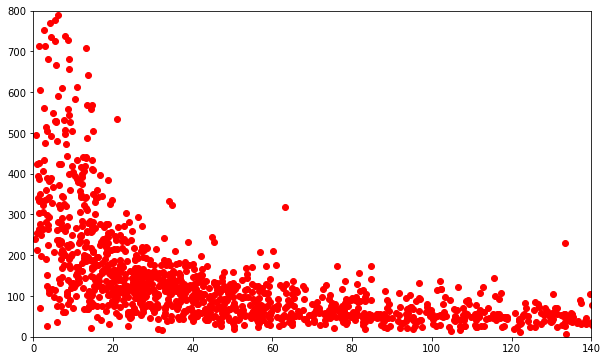

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(df["MU total [mas/yr]"],df['Distanc. [pc]'],'ro')
plt.xlim(0,140)
plt.ylim(0,800)

Podemos observar que existe una relación entre estas dos variables,, ya que el movimiento propio de un astro se espera que sea menor mientras mas lejos este y mayor mientras mas cerca este.

###  f) Calcule la velocidad tangencial (perpendicular a la linea de visión) de las estrellas. Si consideramos que ésta es constante, ¿cómo cambiaría el movimiento propio total en 400 años?

In [ ]:
masks=(rad/(1000*365*86400*3600)) #conversion de mas/yr a rad/s
ksmas= 1/masks #conversion de rad/s a mas/yr

In [ ]:
df['Vel. Tan.[km/s]']=df["MU total [mas/yr]"]*df['Distanc. [pc]']*masks*3.086e+13
df

,ID,AR [°],DEC [°],mu-ra*cos(dec) [mas/yr],mu-dec [mas/yr],plx [mas],radvel [km/s],PreΔα,PreΔδ,NutΔα,NutΔδ,MuΔα,MuΔδ,Distanc. [pc],MU total [mas/yr],Vel. Tan.[km/s]
0,* tau Cyg,318.798931,38.188081,196.990,410.280,49.1600,-20.900,0.232637,0.098066,-0.132875,0.042028,1.281634e-03,2.669318e-03,20.341741,455.120576,43.921663
1,* sig Cyg,319.446294,39.537911,-0.130,-3.580,1.1300,-5.300,0.230238,0.099040,-0.137910,0.044213,-8.457915e-07,-2.329180e-05,884.955752,3.582360,15.040245
2,* 6 Lac,337.760053,43.345664,-1.980,-5.360,1.9000,-8.700,0.253595,0.120603,-0.115446,0.101719,-1.288205e-05,-3.487263e-05,526.315789,5.714018,14.267641
3,* 11 Lac,340.272915,44.507953,93.830,10.710,9.8000,-11.530,0.256893,0.122647,-0.113168,0.108930,6.104663e-04,6.968021e-05,102.040816,94.439256,45.718362
4,* psi And,356.726435,46.700645,8.446,-7.143,1.6352,-23.163,0.291896,0.130084,-0.074044,0.150333,5.495042e-05,-4.647299e-05,611.545988,11.061526,32.092856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,* 32 Eri A,58.886270,-2.706056,26.330,0.079,9.4562,26.300,0.294223,0.067658,0.018951,0.181019,1.713053e-04,5.139810e-07,105.750724,26.330119,13.209925
1593,* del Ser A,233.955635,10.275343,-73.952,5.748,10.8056,-20.820,0.280405,-0.076885,-0.024893,-0.186665,-4.811382e-04,3.739700e-05,92.544607,74.175048,32.566653
1594,* phi Per,26.299878,50.998086,24.590,-14.010,4.5400,0.800,0.370063,0.117019,0.014497,0.192427,1.599847e-04,-9.115030e-05,220.264317,28.301028,29.574032
1595,* alf Eri,24.661068,-56.927015,87.000,-38.240,23.3900,18.600,0.216011,0.118539,0.015970,0.191448,5.660297e-04,-2.487928e-04,42.753313,95.033139,19.275650


Para hallar el moviento propio total despues de 400 años hay que hacer el siguiente procedimiento el cual consiste en

* primero hallar la nueva distancia que recorrio despues de los 400 años con la velocidad radial
+ luego hallar el movimiento propio total con la velocidad tangencial con la nueva distancia

In [ ]:
nuevadistancia= df['Distanc. [pc]']*(3.086e+13) + df['radvel [km/s]']* 400*365*86400

In [ ]:
Munew= df['Vel. Tan.[km/s]']/nuevadistancia * ksmas

In [ ]:
df['MU new [mas/yr]']=Munew
df

,ID,AR [°],DEC [°],mu-ra*cos(dec) [mas/yr],mu-dec [mas/yr],plx [mas],radvel [km/s],PreΔα,PreΔδ,NutΔα,NutΔδ,MuΔα,MuΔδ,Distanc. [pc],MU total [mas/yr],Vel. Tan.[km/s],MU new [mas/yr]
0,* tau Cyg,318.798931,38.188081,196.990,410.280,49.1600,-20.900,0.232637,0.098066,-0.132875,0.042028,1.281634e-03,2.669318e-03,20.341741,455.120576,43.921663,455.311798
1,* sig Cyg,319.446294,39.537911,-0.130,-3.580,1.1300,-5.300,0.230238,0.099040,-0.137910,0.044213,-8.457915e-07,-2.329180e-05,884.955752,3.582360,15.040245,3.582368
2,* 6 Lac,337.760053,43.345664,-1.980,-5.360,1.9000,-8.700,0.253595,0.120603,-0.115446,0.101719,-1.288205e-05,-3.487263e-05,526.315789,5.714018,14.267641,5.714056
3,* 11 Lac,340.272915,44.507953,93.830,10.710,9.8000,-11.530,0.256893,0.122647,-0.113168,0.108930,6.104663e-04,6.968021e-05,102.040816,94.439256,45.718362,94.443618
4,* psi And,356.726435,46.700645,8.446,-7.143,1.6352,-23.163,0.291896,0.130084,-0.074044,0.150333,5.495042e-05,-4.647299e-05,611.545988,11.061526,32.092856,11.061698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,* 32 Eri A,58.886270,-2.706056,26.330,0.079,9.4562,26.300,0.294223,0.067658,0.018951,0.181019,1.713053e-04,5.139810e-07,105.750724,26.330119,13.209925,26.327442
1593,* del Ser A,233.955635,10.275343,-73.952,5.748,10.8056,-20.820,0.280405,-0.076885,-0.024893,-0.186665,-4.811382e-04,3.739700e-05,92.544607,74.175048,32.566653,74.181870
1594,* phi Per,26.299878,50.998086,24.590,-14.010,4.5400,0.800,0.370063,0.117019,0.014497,0.192427,1.599847e-04,-9.115030e-05,220.264317,28.301028,29.574032,28.300986
1595,* alf Eri,24.661068,-56.927015,87.000,-38.240,23.3900,18.600,0.216011,0.118539,0.015970,0.191448,5.660297e-04,-2.487928e-04,42.753313,95.033139,19.275650,95.016242


Como podemos observar, para las estrellas que se acercan el movimiento propio aumenta, a diferencia de las estrellas que se alejan, que podemos observar como su movimiento propio disminuye, ya que tienen una relacion inversamente proporcional a la distancia.


## El sol y la duracion del dia

### (a) Utilice astroquery para obtener los datos observacionales del Sol para cada día del año 2022, tomando como punto de referencia el baricentro terrestre.

In [ ]:
!pip install astroquery

In [ ]:
!pip install julian


In [ ]:
from astroquery.jplhorizons import Horizons
from julian import to_jd

In [ ]:
dic = {'start':'2022-01-01', 'stop':'2022-12-31','step':'1d'}

sun = Horizons(id = 'sun', location="@0", epochs = dic)



In [ ]:
eph = sun.ephemerides()
eph

targetname,datetime_str,datetime_jd,solar_presence,flags,RA,DEC,RA_app,DEC_app,RA_rate,DEC_rate,AZ,EL,AZ_rate,EL_rate,sat_X,sat_Y,sat_PANG,siderealtime,airmass,magextinct,V,surfbright,illumination,illum_defect,sat_sep,sat_vis,ang_width,PDObsLon,PDObsLat,PDSunLon,PDSunLat,SubSol_ang,SubSol_dist,NPole_ang,NPole_dist,EclLon,EclLat,r,r_rate,delta,delta_rate,lighttime,vel_sun,vel_obs,elong,elongFlag,alpha,IB_elong,IB_illum,sat_alpha,sunTargetPA,velocityPA,OrbPlaneAng,constellation,TDB-UT,ObsEclLon,ObsEclLat,NPole_RA,NPole_DEC,GlxLon,GlxLat,solartime,earth_lighttime,RA_3sigma,DEC_3sigma,SMAA_3sigma,SMIA_3sigma,Theta_3sigma,Area_3sigma,RSS_3sigma,r_3sigma,r_rate_3sigma,SBand_3sigma,XBand_3sigma,DoppDelay_3sigma,true_anom,hour_angle,alpha_true,PABLon,PABLat
---,---,d,---,---,deg,deg,deg,deg,arcsec / h,arcsec / h,deg,deg,arcsec / min,arcsec / min,arcsec,arcsec,deg,---,---,mag,mag,mag / arcsec2,%,arcsec,arcsec,---,arcsec,deg,deg,deg,deg,deg,arcsec,deg,arcsec,deg,deg,AU,km / s,AU,km / s,min,km / s,km / s,deg,---,deg,deg,%,deg,deg,deg,deg,---,s,deg,deg,deg,deg,deg,deg,---,min,arcsec,arcsec,arcsec,arcsec,deg,arcsec2,arcsec,km,km / s,Hz,Hz,s,deg,---,deg,deg,deg
str8,str17,float64,str1,str1,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,str1,float64,float64,float64,int64,int64,str3,int64,float64,str9,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,str2,float64,int64,int64,float64,float64,float64,float64,str3,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float64,float64,float64
Sun (10),2022-Jan-01 00:00,2459580.5,,,160.71768,9.30924,160.71768,9.30924,7.906362,-3.05852,--,--,--,--,0.0,0.0,0.0,--,999,--,-36.92,-10.589,100.0,0.0,0.0,-,218403.7,21.053356,6.119738,--,--,n.a,--,21.1611,*********,--,--,0.0,0.0,0.00921213259113,0.0001042,0.07661497,0.0,0.0157335,0.0,/?,0.0,--,--,0.0,0.0,180.0,0.0,Leo,69.183891,158.6912605,1.0766179,286.13,63.87,237.231361,54.827304,--,8.218649,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0.0,158.6913,1.0766
Sun (10),2022-Jan-02 00:00,2459581.5,,,160.77108,9.28885,160.77108,9.28885,7.904203,-3.05906,--,--,--,--,0.0,0.0,0.0,--,999,--,-36.92,-10.589,100.0,0.0,0.0,-,218402.1,6.925789,6.119723,--,--,n.a,--,21.1758,*********,--,--,0.0,0.0,0.00921219159314,0.0001001,0.07661546,0.0,0.0157302,0.0,/?,0.0,--,--,0.0,0.0,180.0,0.0,Leo,69.18392,158.7477729,1.0775133,286.13,63.87,237.312625,54.858986,--,8.219653,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0.0,158.7478,1.0775
Sun (10),2022-Jan-03 00:00,2459582.5,,,160.82447,9.26845,160.82447,9.26845,7.902039,-3.05958,--,--,--,--,0.0,0.0,0.0,--,999,--,-36.92,-10.589,100.0,0.0,0.0,-,218400.6,352.79821,6.119701,--,--,n.a,--,21.1905,*********,--,--,0.0,0.0,0.00921224821471,9.6e-05,0.07661593,0.0,0.0157269,0.0,/?,0.0,--,--,0.0,0.0,180.0,0.0,Leo,69.18395,158.8042731,1.0784074,286.13,63.87,237.393999,54.890606,--,8.220676,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0.0,158.8043,1.0784
Sun (10),2022-Jan-04 00:00,2459583.5,,,160.87784,9.24806,160.87784,9.24806,7.89987,-3.0601,--,--,--,--,0.0,0.0,0.0,--,999,--,-36.92,-10.589,100.0,0.0,0.0,-,218399.2,338.670619,6.119674,--,--,n.a,--,21.2051,*********,--,--,0.0,0.0,0.00921230249772,9.2e-05,0.07661638,0.0,0.0157236,0.0,/?,0.0,--,--,0.0,0.0,180.0,0.0,Leo,69.183979,158.8607612,1.0793003,286.13,63.87,237.475483,54.922166,--,8.221715,--,--,--,--,--,--,--,--,--,--,--,--,--,--,0.0,158.8608,1.0793
Sun (10),2022-Jan-05 00:00,2459584.5,,,160.93119,9.22765,160.93119,9.22765,7.897693,-3.0606,--,--,--,--,0.0,0.0,0.0,--,999,--,-36.92,-10.589,100.0,0.0,0.0,-,218397.9,324.543015,6.119641,--,--,n.a,--,21.2198,*********,--,--,0.0,0.0,0.00921235448693,8.81e-05,0.07661682,0.0,0.0157202,0.0,/?,0.0,--,--,0.0,0.0,180.0,0.0,Leo,69.184009,158.917237,1.080192,286.13,63.87,237.557077,54.953664,--,8.222772,--,--,--,--,--,--,--,--,--,--,--,

In [ ]:
#sacamos valores importantes

ARsun= eph['RA_app']  #Asencion recta aparente
DECsun= eph['DEC_app']#Declinacion aparente

data={'fecha':eph['datetime_str'],'ARsun':ARsun,'DECsun':DECsun}

df2 = pd.DataFrame(data)
df2['fecha'] = pd.to_datetime(df2['fecha'])
df2

,fecha,ARsun,DECsun
0,2022-01-01,160.71768,9.30924
1,2022-01-02,160.77108,9.28885
2,2022-01-03,160.82447,9.26845
3,2022-01-04,160.87784,9.24806
4,2022-01-05,160.93119,9.22765
...,...,...,...
360,2022-12-27,179.71581,1.56963
361,2022-12-28,179.76820,1.54744
362,2022-12-29,179.82059,1.52526
363,2022-12-30,179.87297,1.50307


### (b) Realice un programa que, dada la ubicación de un observador y con los datos  descargados, calcule:



#### • El ángulo horario y acimut de salida del Sol (haga las consideraciones necesarias).



In [ ]:
# Para calcular el angulo horario de salida de sol consideramos que la altura en este caso es 0, h=0

#definimos la funcion para calcular  el angulo horario

def Hsp(ϕ,δ):

    h=-16/60
    h= h* rad

    if δ>= 90- ϕ:
        Hs=" Es circumpolar"
        Hp=" Es circumpolar"

    else:
        ϕ= ϕ*rad
        δ= δ*rad

        Hp= np.arccos((np.sin(h)/(np.cos(δ)*np.cos(ϕ))-np.tan(ϕ)*np.tan(δ)))
        #Hp=np.arccos(-np.tan(ϕ)*np.tan(δ))
        Hs = 2*np.pi - Hp

    return (Hs*grad)/15,(Hp*grad)/15




def Asp(ϕ,δ):

    ϕ= ϕ*rad
    δ= δ*rad

    As= np.arccos(np.sin(δ)/np.cos(ϕ))
    Ap=2*np.pi - As

    return (As*grad)/15,(Ap*grad)/15



#### • Su altura máxima geométrica y aparente (suponga condiciones sobre el nivel del mar).



Para calcular la altura maxima que alcanza un cuerpo considermaos que es el momento donde el cuerpo culmina, es decir H=0. Ademas, al momento de calcular la altura maxima hay que tener en cuenta tambien si el cuerpo para por el meridiado al norte del cenir o a sur del cenit.Ya que dependiento a este es que se calculá la altura maxima Que en este caso sería la altura geometrica.

Para el calculo de la altura aparente tenemos que tener en cuenta los efectos de la refraccion atmosferica, y para esto podemos utilizar las siguientes ecuaciones para calcular esa refraccion

Para alturas mayores a 15° es
$$ R = \frac{P}{T+273} * 0.00452 tan(90 - h)$$

Para alturas menores a 15° es

$$ R = \frac{P}{T+273} *  \frac{0.1594 + 0.0196h + 0.00002h^2}{1+0.0505h + 0.0845h^2} )$$

Para luego sumarselo al geometrico para darnos el aparente


In [ ]:
#funcion para calcular la altura maxima

def hmax(ϕ,δ):

    #Calculamos la altura geometrica

    #si culmina al norte del cenit
    if ϕ>δ:
        hg = 90  - ϕ+ δ

    #si culmina al sur del cenir
    elif ϕ<δ:
        hg = 90 + ϕ- δ

    #calculamos la altura aparente
    P=1013.25   #presion atmosferica en milibares
    T=25        #aproximamos la temperatura de la atmosfera

    if hg<15:
        R= (P / (T+273)) * ((0.1594 + 0.0196*hg + 0.00002*hg**2 ) / (1+0.0505*hg + 0.0845*hg**2) )

    elif hg>15:
        hg=hg*rad
        R= (P / (T+273)) * (0.00452 * np.tan(90 - hg))
        hg=hg*grad
        R= R*grad

    ha= hg  + R


    return hg,ha

#### • Su hora de salida, de puesta (si aplican) y de culminación.


aqui definimos el codigo que puesta y de salida, y nos sirve tambien para la culminacion tomando en cuenta que si queremos hallar la hora de culminacion simplemente hay que colocar H=0 al momento de evaluar la funcion





In [ ]:


def hora(H,α,fecha,λ,HH):

    f= 1.0027379

    #primero hallamos el TSL(tiempo sideral local)
    TSL= (H + α/ 15)%24

    #Hallamos el TSG0(Tiempo sideral en greenween)
    Fj= to_jd(fecha, fmt='jd')
   # Fj=pd.to_datetime(fecha).to_julian_date()
    T=(Fj-2451545.5)/36525
    TSG0= TSG0 = 6 + 41/60 + 50.54841/3600 + (2400 + 3/60 + 4.81286/3600)*T + 0.09310/3600 * T**2  # en horas

    if TSG0>24:
        TSG0 = TSG0 - int(TSG0/24)*24 #Pasar al primer reloj
    if TSG0<0:
        TSG0 = 24 + (TSG0 - int(TSG0/24)*24) #Pasar al primer reloj


    #Hallamos tiempo sideran en greenweech
    TSG=((TSL - (λ/15)))%24

    #Hallamos el tiempo solar
    UT=((TSG - TSG0)/f)%24

    #hora local
    TL = (UT + HH)%24


    return TL




#### • La duración del día, es decir, el tiempo que el Sol permanece sobre el horizonte.

In [ ]:
#def duracion(Ts,Tp):
 #   d = abs(Ts - Tp)
  #  return d

def duracion(Hs,Hp):
    d = abs(Hs - Hp)
    return d

### (c) Seleccione diferentes ciudades alrededor del globo
 (tome ciudades con latitudes cercanas a 67°, 30°, 0°, −20° y -40°) y utilice su programa para calcular la información solicitada en las ciudades seleccionadas.

In [ ]:
houston=pd.DataFrame()
rognan =pd.DataFrame()
quito  =pd.DataFrame()
belo   =pd.DataFrame()
stanley=pd.DataFrame()


#### Houston (USA)

In [ ]:
ϕhou =  29.7604267
λhou = -95.3698028
HHhou = -5

• El ángulo horario y acimut de salida del Sol

In [ ]:
#Para el angulo horario

HsHou = pd.Series(Hsp(ϕhou,i)[0] for i in DECsun)
HpHou = pd.Series(Hsp(ϕhou,i)[1] for i in DECsun)
houston['HsHou[h]']=HsHou
houston['HpHou[h]']=HpHou

#Para el azimut
AsHou = pd.Series(Asp(ϕhou,i)[0] for i in DECsun)
ApHou = pd.Series(Asp(ϕhou,i)[1] for i in DECsun)

houston['AsHou[h]']=AsHou
houston['ApHou[h]']=ApHou


• Su altura máxima geométrica y aparente

In [ ]:
hgHou = pd.Series(hmax(ϕhou,i)[0] for i in DECsun)
haHou = pd.Series(hmax(ϕhou,i)[1] for i in DECsun)
houston['hgHou[h]']=hgHou
houston['haHou[h]']=haHou


• Su hora de salida, de puesta (si aplican) y de culminación.

In [ ]:
TlsHou = pd.Series((hora(HsHou, i, j, λhou, HHRog)[0] for i, j in zip(ARsun, df2['fecha'])))
TlpHou = pd.Series((hora(HpHou, i, j, λhou, HHRog)[0] for i, j in zip(ARsun, df2['fecha'])))

houston['TlsHou[h]']=TlsHou
houston['TlpHou[h]']=TlpHou

• La duración del día, es decir, el tiempo que el Sol permanece sobre el horizonte.

In [ ]:
diaHou = duracion(HsHou,HpHou)
houston['DiaHou[h]']=diaHou

houston

,HsHou[h],HpHou[h],AsHou[h],ApHou[h],hgHou[h],haHou[h],TlsHou[h],TlpHou[h],DiaHou[h]
0,17.620607,6.379393,5.284051,18.715949,69.548813,70.495464,6.006322,18.730271,11.241215
1,17.621411,6.378589,5.285623,18.714377,69.528423,70.475750,5.944342,18.668290,11.242821
2,17.622214,6.377786,5.287197,18.712803,69.508023,70.456027,5.882361,18.606310,11.244428
3,17.623017,6.376983,5.288769,18.711231,69.487633,70.436313,5.820379,18.544328,11.246034
4,17.623821,6.376179,5.290344,18.709656,69.467223,70.416581,5.758396,18.482344,11.247642
...,...,...,...,...,...,...,...,...,...
360,17.919660,6.080340,5.879455,18.120545,61.809203,63.057990,7.612929,20.402407,11.839319
361,17.920507,6.079493,5.881159,18.118841,61.787013,63.036828,7.550881,20.340360,11.841013
362,17.921353,6.078647,5.882863,18.117137,61.764833,63.015676,7.488834,20.278313,11.842706
363,17.922200,6.077800,5.884567,18.115433,61.742643,62.994516,7.426786,20.216265,11.844400


####  Rognan  (Noruega)

In [ ]:
ϕRog= 67.0952780
λRog= 15.3877832
HHRog=2

• El ángulo horario y acimut de salida del Sol

In [ ]:
#Para el angulo horario

HsRog = pd.Series(Hsp(ϕRog,i)[0] for i in DECsun)
HpRog = pd.Series(Hsp(ϕRog,i)[1] for i in DECsun)
rognan['HsRog[h]']=HsRog
rognan['HpRog[h]']=HpRog

#Para el azimut
AsRog = pd.Series(Asp(ϕRog,i)[0] for i in DECsun)
ApRog = pd.Series(Asp(ϕRog,i)[1] for i in DECsun)
rognan['AsRog[h]']=AsRog
rognan['ApRog[h]']=ApRog

• Su altura máxima geométrica y aparente

In [ ]:
hgRog = pd.Series(hmax(ϕRog,i)[0] for i in DECsun)
haRog = pd.Series(hmax(ϕRog,i)[1] for i in DECsun)
rognan['hgRog[h]']=hgRog
rognan['haRog[h]']=haRog

• Su hora de salida, de puesta (si aplican) y de culminación.

In [ ]:
TlsRog = pd.Series((hora(HsRog, i, j, λhou, HHRog)[0] for i, j in zip(ARsun, df2['fecha'])))
TlpRog = pd.Series((hora(HpRog, i, j, λhou, HHRog)[0] for i, j in zip(ARsun, df2['fecha'])))

rognan['TlsRog[h]']=TlsRog
rognan['TlpRog[h]']=TlpRog

• La duración del día, es decir, el tiempo que el Sol permanece sobre el horizonte.

In [ ]:
diaRog = duracion(HsRog,HpRog)
rognan['DiaRog[h]']=diaRog
rognan

,HsRog[h],HpRog[h],AsRog[h],ApRog[h],hgRog[h],haRog[h],TlsRog[h],TlpRog[h],DiaRog[h]
0,16.427762,7.572238,4.362735,19.637265,32.213962,41.204667,4.816734,19.985389,8.855524
1,16.431369,7.568631,4.366524,19.633476,32.193572,41.217378,4.754754,19.923409,8.862738
2,16.434976,7.565024,4.370313,19.629687,32.173172,41.230338,4.692773,19.861428,8.869951
3,16.438579,7.561421,4.374099,19.625901,32.152782,41.243537,4.630791,19.799446,8.877157
4,16.442183,7.557817,4.377887,19.622113,32.132372,41.256997,4.568808,19.737463,8.884366
...,...,...,...,...,...,...,...,...,...
360,17.706289,6.293711,5.730947,18.269053,24.474352,0.973108,6.423340,21.591995,11.412577
361,17.709803,6.290197,5.734756,18.265244,24.452162,1.191686,6.361293,21.529948,11.419606
362,17.713316,6.286684,5.738563,18.261437,24.429982,1.405292,6.299246,21.467901,11.426632
363,17.716830,6.283170,5.742371,18.257629,24.407792,1.614266,6.237198,21.405853,11.433660


####  Quito (Ecuador)

In [ ]:
ϕquito= 0.1806531
λquito= -78.4678382

• El ángulo horario y acimut de salida del Sol

In [ ]:
#Para el angulo horarquito
Hsquito = pd.Series(Hsp(ϕquito,i)[0] for i in DECsun)
Hpquito = pd.Series(Hsp(ϕquito,i)[1] for i in DECsun)
quito['Hsquito[h]']=Hsquito
quito['Hpquito[h]']=Hpquito

#Para el azimut
Asquito = pd.Series(Asp(ϕquito,i)[0] for i in DECsun)
Apquito = pd.Series(Asp(ϕquito,i)[1] for i in DECsun)

quito['Asquito[h]']=Asquito
quito['Apquito[h]']=Apquito



• Su altura máxima geométrica y aparente

In [ ]:
hgquito = pd.Series(hmax(ϕquito,i)[0] for i in DECsun)
haquito = pd.Series(hmax(ϕquito,i)[1] for i in DECsun)
quito['hgquito[h]']=hgquito
quito['haquito[h]']=haquito

• Su hora de salida, de puesta (si aplican) y de culminación.

In [ ]:
Tlsquito = pd.Series((hora(Hsquito, i, j, λhou, HHRog)[0] for i, j in zip(ARsun, df2['fecha'])))
Tlpquito = pd.Series((hora(Hpquito, i, j, λhou, HHRog)[0] for i, j in zip(ARsun, df2['fecha'])))

quito['Tlsquito[h]']=Tlsquito
quito['Tlpquito[h]']=Tlpquito

• La duración del día, es decir, el tiempo que el Sol permanece sobre el horizonte.

In [ ]:
diaquito = duracion(Hsquito,Hpquito)
quito['Diaquito[h]']=diaquito
quito

,Hsquito[h],Hpquito[h],Asquito[h],Apquito[h],hgquito[h],haquito[h],Tlsquito[h],Tlpquito[h],Diaquito[h]
0,17.980011,6.019989,5.379381,18.620619,80.871413,81.505300,6.364744,18.371849,11.960021
1,17.980016,6.019984,5.380740,18.619260,80.891803,81.525214,6.302764,18.309869,11.960032
2,17.980022,6.019978,5.382100,18.617900,80.912203,81.545139,6.240783,18.247888,11.960043
3,17.980027,6.019973,5.383460,18.616540,80.932593,81.565053,6.178801,18.185906,11.960054
4,17.980032,6.019968,5.384820,18.615180,80.953003,81.584988,6.116818,18.123922,11.960065
...,...,...,...,...,...,...,...,...,...
360,17.981885,6.018115,5.895357,18.104643,88.611023,89.079408,7.971351,20.043985,11.963771
361,17.981890,6.018110,5.896837,18.103163,88.633213,89.101160,7.909303,19.981938,11.963781
362,17.981895,6.018105,5.898315,18.101685,88.655393,89.122903,7.847256,19.919891,11.963790
363,17.981900,6.018100,5.899795,18.100205,88.677583,89.144656,7.785208,19.857843,11.963800


#### Belo horizontte (Brazil)

In [ ]:
ϕbelo= -19.9190520
λbelo= -43.9386685
HHbelo=-3

• El ángulo horario y acimut de salida del Sol

In [ ]:
#Para el angulo horario

Hsbelo = pd.Series(Hsp(ϕbelo,i)[0] for i in DECsun)
Hpbelo = pd.Series(Hsp(ϕbelo,i)[1] for i in DECsun)
belo['Hsbelo[h]']=Hsbelo
belo['Hpbelo[h]']=Hpbelo

#Para el azimut
Asbelo = pd.Series(Asp(ϕbelo,i)[0] for i in DECsun)
Apbelo = pd.Series(Asp(ϕbelo,i)[1] for i in DECsun)

belo['Asbelo[h]']=Asbelo
belo['Apbelo[h]']=Apbelo

• Su altura máxima geométrica y aparente

In [ ]:
hgbelo = pd.Series(hmax(ϕbelo,i)[0] for i in DECsun)
habelo = pd.Series(hmax(ϕbelo,i)[1] for i in DECsun)
belo['hgbelo[h]']=hgbelo
belo['habelo[h]']=habelo

• Su hora de salida, de puesta (si aplican) y de culminación.

In [ ]:
Tlsbelo = pd.Series((hora(Hsbelo, i, j, λhou, HHbelo)[0] for i, j in zip(ARsun, df2['fecha'])))
Tlpbelo = pd.Series((hora(Hpbelo, i, j, λhou, HHbelo)[0] for i, j in zip(ARsun, df2['fecha'])))

belo['Tlsbelo[h]']=Tlsbelo
belo['Tlpbelo[h]']=Tlpbelo

• La duración del día, es decir, el tiempo que el Sol permanece sobre el horizonte.

In [ ]:
diabelo = duracion(Hsbelo,Hpbelo)
belo['Diabelo[h]']=diabelo
belo

,Hsbelo[h],Hpbelo[h],Asbelo[h],Apbelo[h],hgbelo[h],habelo[h],Tlsbelo[h],Tlpbelo[h],Diabelo[h]
0,18.207835,5.792165,5.339507,18.660493,60.771708,62.069780,1.591946,13.144647,12.415669
1,18.207329,5.792671,5.340955,18.659045,60.792098,62.089176,1.529966,13.082667,12.414658
2,18.206824,5.793176,5.342404,18.657596,60.812498,62.108583,1.467985,13.020686,12.413647
3,18.206318,5.793682,5.343853,18.656147,60.832888,62.127981,1.406003,12.958704,12.412637
4,18.205813,5.794187,5.345303,18.654697,60.853298,62.147399,1.344020,12.896720,12.411625
...,...,...,...,...,...,...,...,...,...
360,18.019013,5.980987,5.888698,18.111302,68.511318,69.493028,3.198553,14.816783,12.038026
361,18.018476,5.981524,5.890271,18.109729,68.533508,69.514454,3.136505,14.754736,12.036953
362,18.017940,5.982060,5.891844,18.108156,68.555688,69.535870,3.074458,14.692689,12.035881
363,18.017404,5.982596,5.893418,18.106582,68.577878,69.557297,3.012410,14.630641,12.034808


####  Stanley (Australia)

In [ ]:
ϕstan= -40.7597041
λstan= 145.2960121
HHstan=10

• El ángulo horario y acimut de salida del Sol

In [ ]:
#Para el angulo horario

Hsstan = pd.Series(Hsp(ϕstan,i)[0] for i in DECsun)
Hpstan = pd.Series(Hsp(ϕstan,i)[1] for i in DECsun)
stanley['Hsstan[h]']=Hsstan
stanley['Hpstan[h]']=Hpstan

#Para el azimut
Asstan = pd.Series(Asp(ϕstan,i)[0] for i in DECsun)
Apstan = pd.Series(Asp(ϕstan,i)[1] for i in DECsun)

stanley['Asstan[h]']=Asstan
stanley['Apstan[h]']=Apstan



• Su altura máxima geométrica y aparente

In [ ]:
hgstan = pd.Series(hmax(ϕstan,i)[0] for i in DECsun)
hastan = pd.Series(hmax(ϕstan,i)[1] for i in DECsun)
stanley['hgstan[h]']=hgstan
stanley['hastan[h]']=hastan

• Su hora de salida, de puesta (si aplican) y de culminación.

In [ ]:
Tlsstan = pd.Series((hora(Hsstan, i, j, λhou, HHstan)[0] for i, j in zip(ARsun, df2['fecha'])))
Tlpstan = pd.Series((hora(Hpstan, i, j, λhou, HHstan)[0] for i, j in zip(ARsun, df2['fecha'])))

stanley['Tlsstan[h]']=Tlsstan
stanley['Tlpstan[h]']=Tlpstan

• La duración del día, es decir, el tiempo que el Sol permanece sobre el horizonte.

In [ ]:
diastan = duracion(Hsstan,Hpstan)
stanley['Diastan[h]']=diastan
stanley

,Hsstan[h],Hpstan[h],Asstan[h],Apstan[h],hgstan[h],hastan[h],Tlsstan[h],Tlpstan[h],Diastan[h]
0,18.517496,5.482504,5.177924,18.822076,39.931056,43.652945,14.900762,1.835831,13.034991
1,18.516283,5.483717,5.179737,18.820263,39.951446,43.667432,14.838782,1.773851,13.032566
2,18.515070,5.484930,5.181551,18.818449,39.971846,43.681944,14.776801,1.711870,13.030139
3,18.513857,5.486143,5.183363,18.816637,39.992236,43.696467,14.714819,1.649888,13.027715
4,18.512644,5.487356,5.185177,18.814823,40.012646,43.711021,14.652835,1.587905,13.025288
...,...,...,...,...,...,...,...,...,...
360,18.066743,5.933257,5.861838,18.138162,47.670666,49.958586,16.507368,3.442438,12.133486
361,18.065467,5.934533,5.863791,18.136209,47.692856,49.978135,16.445321,3.380390,12.130934
362,18.064192,5.935808,5.865744,18.134256,47.715036,49.997681,16.383274,3.318343,12.128383
363,18.062916,5.937084,5.867697,18.132303,47.737226,50.017241,16.321226,3.256295,12.125831


### (e) Observe cuáles fueron los días más cortos y más largos en cada ubicación.
¿Coincide con lo esperado? Explique.

In [ ]:
diamaxhou=max(diaHou)
diaminhou=min(diaHou)
print('Dia mas largo en Houston=',diamaxhou,'dia mas corto=',diaminhou)

diamaxRog=max(diaRog)
diaminRog=min(diaRog)
print('Dia mas largo en rognan=',diamaxRog,'dia mas corto=',diaminRog)

diamaxquito=max(diaquito)
diaminquito=min(diaquito)
print('Dia mas largo en quito=',diamaxquito,'dia mas corto=',diaminquito)

diamaxbelo=max(diabelo)
diaminbelo=min(diabelo)
print('Dia mas largo en Belo=',diamaxbelo,'dia mas corto=',diaminbelo)


diamaxstan=max(diastan)
diaminstan=min(diastan)
print('Dia mas largo en Stanley=',diamaxstan,'dia mas corto=',diaminstan)


Dia mas largo en Houston= 11.846092612439357 dia mas corto= 11.241214869653852
Dia mas largo en rognan= 11.440683743331508 dia mas corto= 8.85552440107157
Dia mas largo en quito= 11.963809675989205 dia mas corto= 11.960021271374847
Dia mas largo en Belo= 12.415669228000619 dia mas corto= 12.033736420641588
Dia mas largo en Stanley= 13.034991380983705 dia mas corto= 12.123280701342061


Se aprecia que las ciuades como Rognan que estan al norte se parecia mas la diferencia entre los dias ya que tienen estaciones por el hecho de tener una latitud muy alta. a diferencia de quito por ejemplo que al estar practicamente ene l ecuador sus dias no cambian mucho durente el año ya que no presentas estaciones y les llega casi la misma cantidad de energia del sol durante el año.